In [1]:
import os
import operator
from typing import Annotated, Literal
from pydantic import BaseModel
from tavily import TavilyClient
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, SystemMessage, ToolMessage
from langchain_core.prompts import ChatPromptTemplate
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_chroma import Chroma
from langchain_core.documents import Document
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.prebuilt import ToolNode
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
loader = PyPDFLoader("../documents/evs_oil_price_shock.pdf")
raw_docs = loader.load()
print(f"Loaded {len(raw_docs)} pages")

Loaded 15 pages


In [3]:
splitter = RecursiveCharacterTextSplitter(chunk_size=900, chunk_overlap=150)
chunks = splitter.split_documents(raw_docs)
print(f"Split into {len(chunks)} chunks")

Split into 51 chunks


In [4]:
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

In [5]:
vectorstore = Chroma(
    collection_name="rag_rewriting",
    embedding_function=embeddings,
)

vectorstore.add_documents(documents=chunks)

print("Vector store ready")

Vector store ready


In [6]:
llm = ChatOpenAI(model="gpt-5-mini")

agent_llm = ChatOpenAI(model="gpt-5-mini")

In [7]:
class AgenticRAGState(MessagesState):
    
    query: str
    retrieved_docs: Annotated[list[Document], operator.add]
    relevant_docs: list[Document]
    context: str
    generation: str
    needs_retrieval: bool
    retrieval_count: int
    max_retrieval_steps: int
    is_relevant: bool
    rewritten_query: str  
    rewrite_count: int    

In [8]:
class RouteDecision(BaseModel):
    
    needs_retrieval: bool

In [9]:
class RelevanceEvaluation(BaseModel):
    
    is_relevant: bool

In [10]:
@tool(response_format="content_and_artifact")
def vector_store_search(query: str, k: int = 3):
    """Search the vector store for relevant document passages.
    Adjust k (default 3) to retrieve more or fewer passages."""
    
    docs = vectorstore.similarity_search(query, k=k)
    context = "\n\n## Vector Store Results\n\n" + "\n\n".join(d.page_content for d in docs)

    return context, docs

In [11]:
@tool(response_format="content_and_artifact")
def web_search(query: str, max_results: int = 3):
    """Search the web for current or real-time information.
    Adjust max_results (default 3) to control how many results are returned."""
    
    client = TavilyClient(api_key=os.environ["TAVILY_API_KEY"])
    
    response = client.search(query, max_results=max_results)
    
    docs = [
        Document(
            page_content=r["content"],
            metadata={"source": r["url"], "title": r.get("title", "")},
        )
        for r in response["results"]
    ]
    
    content = "\n\n## Web Search Results\n\n" + "\n\n".join(d.page_content for d in docs)
    
    return content, docs

In [12]:
tools = [vector_store_search, web_search]

agent_llm_with_tools = agent_llm.bind_tools(tools)

tool_node = ToolNode(tools)

In [13]:
def route_question(state: AgenticRAGState) -> dict:
    prompt_template = ChatPromptTemplate.from_messages([
        ("system", "Classify whether the following question requires retrieving information from a specialized document or the web, or can be answered from your own general knowledge."),
        ("human", "{query}"),
    ])
    
    chain = prompt_template | llm.with_structured_output(RouteDecision)
    decision = chain.invoke({"query": state["query"]})
    
    return {"needs_retrieval": decision.needs_retrieval}

In [14]:
AGENT_SYSTEM_PROMPT = (
    "You are a retrieval agent with access to two tools:\n\n"
    "1. vector_store_search — use this for questions that can be answered from the internal document: "
    "a technical report titled 'Will EVs Dampen the Oil Price Shock?' covering EV adoption trajectories, "
    "oil demand displacement scenarios, fleet turnover dynamics, battery cost trends, OPEC+ supply behavior, "
    "and energy price volatility projections through 2050. "
    "Use this tool whenever the query references the report, its findings, its projections, or any topic "
    "that would plausibly appear in a domain-specific EV/oil-market research document. "
    "You may increase k beyond the default if broader coverage of the document is needed.\n\n"
    "2. web_search — use this for current or real-time information not covered by the document, such as "
    "recent market data, news, or statistics from 2024 onward. "
    "Always rephrase the query into a concise, keyword-optimized web search string before calling this tool.\n\n"
    "You may call one tool, both tools, or no tool depending on what the query requires. "
    "When both document knowledge and current data are relevant, call both tools."
)

def agent(state: AgenticRAGState) -> dict:
    # use rewritten_query if available to start a fresh retrieval cycle
    rewritten = state.get("rewritten_query")
    
    if rewritten:
        messages = [
            SystemMessage(content=AGENT_SYSTEM_PROMPT),
            HumanMessage(content=rewritten),
        ]
    
    else:
        messages = state["messages"]
        if not messages:
            messages = [
                SystemMessage(content=AGENT_SYSTEM_PROMPT),
                HumanMessage(content=state["query"]),
            ]
    
    response = agent_llm_with_tools.invoke(messages)
    return {"messages": [response]}

In [15]:
def collect_tool_output(state: AgenticRAGState) -> dict:
    tool_messages = [m for m in state["messages"] if isinstance(m, ToolMessage)]
    all_docs = []
    for msg in tool_messages:
        all_docs.extend(msg.artifact)
    return {"retrieved_docs": all_docs}

In [16]:
def evaluate_docs(state: AgenticRAGState) -> dict:
    docs = state.get("retrieved_docs") or []
    if not docs:
        return {"is_relevant": False, "relevant_docs": [], "context": ""}

    active_query = state.get("rewritten_query") or state["query"]

    prompt_template = ChatPromptTemplate.from_messages([
        (
            "system",
            "You are a relevance evaluator. Given a user query and a single document passage, "
            "determine whether the passage contains useful information to answer the query. "
            "Return is_relevant=True only if the passage directly addresses the query with specific facts or analysis. "
            "Return is_relevant=False if it is off-topic, too vague, or does not help answer the query."
        ),
        ("human", "Query: {query}\n\nDocument passage:\n{doc}"),
    ])
    chain = prompt_template | llm.with_structured_output(RelevanceEvaluation)

    relevant_docs = []
    for doc in docs:
        result = chain.invoke({"query": active_query, "doc": doc.page_content})
        if result.is_relevant:
            relevant_docs.append(doc)

    is_relevant = len(relevant_docs) > 0
    
    context = "\n\n".join(d.page_content for d in relevant_docs)

    return {"is_relevant": is_relevant, "relevant_docs": relevant_docs, "context": context}

In [17]:
def rewrite_query(state: AgenticRAGState) -> dict:
    count = state.get("rewrite_count", 0)

    prompt_template = ChatPromptTemplate.from_messages([
        (
            "system",
            "You are a query rewriting assistant. A retrieval system searched for information to answer the user's "
            "query but none of the retrieved documents were relevant. Your task is to rewrite the query to be more "
            "specific, use different terminology, or focus on a narrower aspect that is more likely to match "
            "content in the knowledge source. Return only the rewritten query string."
        ),
        ("human", "Original query: {query}\n\nRewritten query:"),
    ])
    
    chain = prompt_template | llm
    response = chain.invoke({"query": state["query"]})
    new_query = response.content.strip()

    return {"rewritten_query": new_query, "rewrite_count": count + 1}

In [18]:
def generate(state: AgenticRAGState) -> dict:
    # no-answer fallback when all rewrite attempts are exhausted with no relevant docs
    if state.get("rewrite_count", 0) >= 3 and not state.get("is_relevant"):
        return {
            "generation": (
                "I was unable to find relevant information to answer your query after multiple retrieval attempts. "
                "The knowledge source does not appear to contain content that addresses this question."
            )
        }

    query = state["query"]
    context = state.get("context") or ""

    if context:
        prompt_template = ChatPromptTemplate.from_messages([
            ("system", "Answer the question using only the context below.\n\nContext:\n{context}"),
            ("human", "{query}"),
        ])
        response = (prompt_template | llm).invoke({"context": context, "query": query})
    else:
        prompt_template = ChatPromptTemplate.from_messages([
            ("system", "Answer the following question from your general knowledge."),
            ("human", "{query}"),
        ])
        response = (prompt_template | llm).invoke({"query": query})

    return {"generation": response.content}

In [19]:
def check_retrieval_limit(state: AgenticRAGState) -> dict:
    count = state.get("retrieval_count", 0)
    return {"retrieval_count": count + 1}

In [20]:
def route_after_classification(state: AgenticRAGState) -> Literal["agent", "generate"]:
    return "agent" if state["needs_retrieval"] else "generate"

def route_after_agent(state: AgenticRAGState) -> Literal["tools", "collect_tool_output"]:
    return "tools" if state["messages"][-1].tool_calls else "collect_tool_output"

def route_after_limit_check(state: AgenticRAGState) -> Literal["agent", "collect_tool_output"]:
    return "collect_tool_output" if state["retrieval_count"] >= state["max_retrieval_steps"] else "agent"

def route_after_evaluation(state: AgenticRAGState) -> Literal["generate", "rewrite_query"]:
    return "generate" if state["is_relevant"] else "rewrite_query"

def route_after_rewrite(state: AgenticRAGState) -> Literal["agent", "generate"]:
    return "generate" if state.get("rewrite_count", 0) >= 3 else "agent"

In [21]:
graph_builder = StateGraph(AgenticRAGState)

graph_builder.add_node("route_question", route_question)
graph_builder.add_node("agent", agent)
graph_builder.add_node("tools", tool_node)
graph_builder.add_node("check_retrieval_limit", check_retrieval_limit)
graph_builder.add_node("collect_tool_output", collect_tool_output)
graph_builder.add_node("evaluate_docs", evaluate_docs)
graph_builder.add_node("rewrite_query", rewrite_query)
graph_builder.add_node("generate", generate)

graph_builder.add_edge(START, "route_question")
graph_builder.add_conditional_edges("route_question", route_after_classification)
graph_builder.add_conditional_edges("agent", route_after_agent)
graph_builder.add_edge("tools", "check_retrieval_limit")
graph_builder.add_conditional_edges("check_retrieval_limit", route_after_limit_check)
graph_builder.add_edge("collect_tool_output", "evaluate_docs")
graph_builder.add_conditional_edges("evaluate_docs", route_after_evaluation)
graph_builder.add_conditional_edges("rewrite_query", route_after_rewrite)
graph_builder.add_edge("generate", END)

In [22]:
graph = graph_builder.compile()

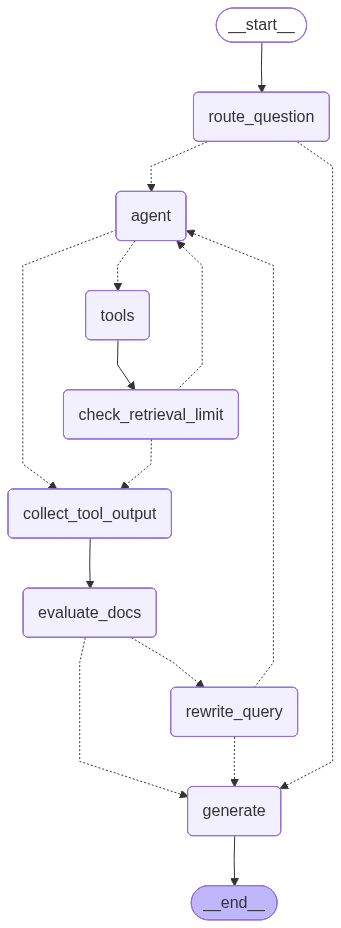

In [23]:
graph

In [ ]:
query_1 = (
    "According to the report, by how many million barrels per day could a 300-million EV fleet "
    "displace oil demand by 2030, and what does this mean relative to total global demand?"
)

result_1 = graph.invoke({
    "query": query_1,
    "messages": [],
    "retrieved_docs": [],
    "relevant_docs": [],
    "context": "",
    "retrieval_count": 0,
    "max_retrieval_steps": 3,
    "rewrite_count": 0,
    "rewritten_query": "",
})

print("=== Case 1: Specific domain query ===")
print("Is relevant:", result_1.get("is_relevant"))
print("Relevant docs count:", len(result_1.get("relevant_docs") or []))
print("Rewrite count:", result_1.get("rewrite_count"))
print("\nGeneration:\n", result_1.get("generation"))

=== Case 1: Specific domain query ===
Is relevant: True
Relevant docs count: 5
Rewrite count: 1

Generation:
 The report says a 300‑million EV fleet would displace about 4.6 million barrels per day by 2030 — a meaningful but not transformative cut, roughly 4–4.6% of global oil demand (against a 100–105 million b/d base).


In [34]:
print(result_1["query"])

According to the report, by how many million barrels per day could a 300-million EV fleet displace oil demand by 2030, and what does this mean relative to total global demand?


In [35]:
print(result_1["rewritten_query"])

How many million barrels per day (mb/d) of oil demand could a global fleet of 300 million electric vehicles displace by 2030, and what percentage or share of projected total global oil demand in 2030 would that represent?


In [33]:
query_2 = (
    "how long people take to get rid of their vehicles completely as per the report?"
)

result_2 = graph.invoke({
    "query": query_2,
    "messages": [],
    "retrieved_docs": [],
    "relevant_docs": [],
    "context": "",
    "retrieval_count": 0,
    "max_retrieval_steps": 3,
    "rewrite_count": 0,
    "rewritten_query": "",
})

print("=== Case 2: Informal query — rewrite then succeeds ===")
print("Is relevant:", result_2.get("is_relevant"))
print("Relevant docs count:", len(result_2.get("relevant_docs") or []))
print("Rewrite count:", result_2.get("rewrite_count"))
print("Rewritten query:", result_2.get("rewritten_query"))
print("\nGeneration:\n", result_2.get("generation"))

=== Case 2: Informal query — rewrite then succeeds ===
Is relevant: True
Relevant docs count: 1
Rewrite count: 0
Rewritten query: 

Generation:
 The report states average vehicle lifetimes are about 15 to 20 years in developed markets — and often longer in developing markets.


In [ ]:
query_3 = "What does the report/document say about nuclear power?"

result_3 = graph.invoke({
    "query": query_3,
    "messages": [],
    "retrieved_docs": [],
    "relevant_docs": [],
    "context": "",
    "retrieval_count": 0,
    "max_retrieval_steps": 3,
    "rewrite_count": 0,
    "rewritten_query": "",
})

print("=== Case 3: Off-topic query — max rewrites exhausted ===")
print("Is relevant:", result_3.get("is_relevant"))
print("Relevant docs count:", len(result_3.get("relevant_docs") or []))
print("Rewrite count:", result_3.get("rewrite_count"))
print("Rewritten query:", result_3.get("rewritten_query"))
print("\nGeneration:\n", result_3.get("generation"))

=== Case 3: Off-topic query — max rewrites exhausted ===
Is relevant: True
Relevant docs count: 1
Rewrite count: 2
Rewritten query: According to the report/document, what conclusions or recommendations are made about nuclear power—specifically regarding its role in decarbonization, safety and accident risk, costs (capital and levelized), radioactive waste management, and policy/timeline recommendations?

Generation:
 The IPCC AR6-WG3 report identifies nuclear energy as one of the three available energy sources—along with wind and solar—that can mitigate climate change by delivering net carbon reductions while also providing net cost savings (SPM.7). The full report did not model potential future cost reductions for advanced nuclear reactors (unlike for some other technologies), but despite that omission it nonetheless highlights nuclear as an important climate-change mitigation strategy. The report’s findings are used to argue that countries should include nuclear in the energy mix nee

In [36]:
print(result_3["relevant_docs"])

[Document(metadata={'source': 'https://nuclearinnovationalliance.org/global-climate-change-mitigation-and-critical-role-nuclear-energy-assessing-intergovernmental-panel', 'title': 'Global Climate Change Mitigation and the Critical Role of Nuclear ...'}, page_content='# Global Climate Change Mitigation and the Critical Role of Nuclear Energy: Assessing the Intergovernmental Panel on Climate Change, AR6-WG3 Report. If not, and current policies are maintained through 2030, it will become “impossible to limit warming to 1.5°C.” The report identified that wind, solar, and nuclear energy are the three available energy sources to mitigate climate change through net carbon reductions and also provide net cost savings (SPM.7). Despite the full Report not considering the potential future cost reductions for advanced reactor technology, as it did for other technologies like carbon capture and renewables, it is significant that nuclear energy was nonetheless identified as an important climate chan

In [37]:
print(len(result_3["retrieved_docs"]))

54


In [ ]:
query_4 = "What is the chemical symbol for lithium and what group of the periodic table does it belong to?"

result_4 = graph.invoke({
    "query": query_4,
    "messages": [],
    "retrieved_docs": [],
    "relevant_docs": [],
    "context": "",
    "retrieval_count": 0,
    "max_retrieval_steps": 3,
    "rewrite_count": 0,
    "rewritten_query": "",
})

print("=== Case 4: General knowledge — no retrieval ===")
print("Needs retrieval:", result_4.get("needs_retrieval"))
print("Is relevant:", result_4.get("is_relevant"))
print("Rewrite count:", result_4.get("rewrite_count"))
print("\nGeneration:\n", result_4.get("generation"))

=== Case 4: General knowledge — no retrieval ===
Needs retrieval: False
Is relevant: None
Rewrite count: 0

Generation:
 The chemical symbol for lithium is Li. It belongs to Group 1 of the periodic table — the alkali metals.
